## Кратко в предыдущих сериях

Что советуем перед семинаром освежить в памяти из курса статистики:

* описательные статистики (среднее, частоту абсолютную и относительную, выборочную медиану и квантили, их поиск с помощью пакета `numpy`);
* генеральную совокупность, выборку. Алгоритмы семплирования с возвращением и без;
* случайные величины, независимость случайных величин, их распределение;
* метод Монте-Карло;
* мат. ожидание и дисперсию;
* ЦПТ;
* точечные и интервальные оценки;
* оценки параметров среднего и пропорции.

# Тема 1. Bootstrap

## 0. Цель и задачи

**Цель** — по выборке оценить её характеристики без применения предположений о генеральной совокупности.

**Задачи:**
- вспомнить статистику (пункты выше);
- узнать, как зависит стандартное отклонение среднего от размера выборки;
- понять, что не всегда можно воспользоваться теоретическими оценками;
- познакомиться с Bootstrap-методом, понять принцип его работы;
- отметить плюсы и минусы метода;
- научиться строить Bootstrap-доверительные интервалы и сравнить их с доверительными интервалами по ЦПТ;
- разобрать на примере работу Bootstrap;
- узнать, как делать Bootstrap, если данные зависят от какой-то характеристики (например, от покупки пользователя).

## 1. Предисловие

### 1.1 Парадокс бразильских школ

В 1990-х годах в Бразилии стало популярным выступать за сокращение размеров школ. Многочисленные благотворительные организации и правительственные учреждения финансировали разделение крупных школ, поскольку небольшие школы чаще представлены в группах с высокими средними результатами теста ENEM (бразильский аналог ЕГЭ).

Если отобрать топ-1% школ по среднему баллу, то мы увидим, что школы, попавшие в этот топ-1%, имеют меньшее число учеников.

<img src="brazil schools.png" width="500">

Почему так?

Посмотрим на зависимость среднего балла от размера школы.

<img src="score from size.png" width="600">

Видим, что маленькие школы чаще имеют как высокий, так и низкий средний балл. Но как так?

### 1.2 Стандартное отклонение

Мы уже знакомы со стандартным отклонением. Напомним, что стандартное отклонение случайной величины $X$ — это $\sigma_X = \sqrt{\mathsf{Var}(X)},$ а $\mathsf{Var}(X)$ — дисперсия случайной величины $X$.

> На курсе по статистике мы уже видели, что при семплировании Монте-Карло выборки размера $n$ и подсчёте среднего получается отклонение порядка $\frac{const}{\sqrt{n}}.$ Сейчас мы получим похожую зависимость.

Пусть нашими наблюдениями $X_1, \ldots, X_n$ будут результаты по ENEM каждого из учеников какой-то из школ. Будем считать эти наблюдения независимыми и одинаково распределёнными случайными величинами. И пусть стандартное отклонение каждого из $X_i$ будет $\sigma$. Попробуем оценить стандартное отклонение среднего балла по всей школе:
$$\sigma_{\overline{X}} = \sqrt{\mathsf{Var}\left(\overline{X}\right)} = \sqrt{\frac{1}{n^2}\mathsf{Var}\left(\sum\limits_{i = 1}^{n}X_i\right)} = \sqrt{\frac{1}{n^2} \mathsf{Var}\left(nX_1\right)} = \frac{\sigma}{\sqrt{n}}.$$

Что мы видим? Отклонение среднего балла напрямую зависит от размера школы: чем больше школа, тем меньше отклонение среднего балла, а значит, средний балл малых школ более подвержен случайным колебаниям: как вверх, так и вниз. Этим и объясняются выбросы в среднем балле у маленьких школ.

> **Вывод:** стандартное отклонение среднего $n$ случайных величин напрямую зависит от $n$ (чем оно больше, тем меньше отклонение среднего). Именно поэтому при малых размерах школ в примере были выбросы в среднем балле в большую и меньшую стороны.

## 2. Непосредственно Bootstrap


### 2.1. Исходная ситуация

- У нас есть **выборка** из наблюдений: $X_1, X_2, \dots, X_n$.
- Мы хотим посчитать какую-то **статистику**: среднее, медиану, разницу между группами, коэффициент регрессии, и т. п.
- Мы **не знаем**, из какого распределения пришли данные.
- Мы **не хотим (или не можем)** делать предположений о виде этого распределения (нормальное, экспоненциальное, что-то ещё).
- Но мы хотим оценить:
  - значение статистики;
  - её **разброс** (например, стандартную ошибку).
  
  Или построить **доверительный интервал**.

---

### 2.2. В чём проблема?

Большинство классических методов статистики (t-тесты, Z-тесты, доверительные интервалы по формулам) предполагают:

- что данные пришли из **заданного распределения** (обычно нормального);
- что наблюдения независимы и одинаково распределены;
- что выборка достаточно **большая**, чтобы сработала центральная предельная теорема.

Но если этих условий **нет**, мы можем получить неверные оценки.

---

### 2.3. Идея Bootstrap

Основная мысль Bootstrap.
> «**Представим**, что наша выборка — это маленькая репрезентативная модель всей реальности».

Нам хочется взять много новых выборок из того же распределения и оценить, например, насколько «скачет» среднее. Но реальность недоступна. Поэтому мы используем то, что есть.

Мы считаем, что **эмпирическое распределение** (набор наших данных, то есть дискретное равномерное распределение на $X_1, \ldots, X_n$) — это честная замена настоящего распределения.

А значит, можно исследовать его поведение, не зная, как устроена «реальность».

> На самом деле, если $X_1, \ldots, X_n$ — <u>выборка</u> (то есть, независимые и одинаково распределённые случайные величины) из неизвестного распрделения $P$, то **эмпирическое** распределение действительно хорошо приближает истинное распределение (подробнее см. [тут](https://ru.wikipedia.org/wiki/%D0%92%D1%8B%D0%B1%D0%BE%D1%80%D0%BE%D1%87%D0%BD%D0%B0%D1%8F_%D1%84%D1%83%D0%BD%D0%BA%D1%86%D0%B8%D1%8F_%D1%80%D0%B0%D1%81%D0%BF%D1%80%D0%B5%D0%B4%D0%B5%D0%BB%D0%B5%D0%BD%D0%B8%D1%8F), [вот тут](https://ru.wikipedia.org/wiki/%D0%A2%D0%B5%D0%BE%D1%80%D0%B5%D0%BC%D0%B0_%D0%93%D0%BB%D0%B8%D0%B2%D0%B5%D0%BD%D0%BA%D0%BE_%E2%80%94_%D0%9A%D0%B0%D0%BD%D1%82%D0%B5%D0%BB%D0%BB%D0%B8) и [вот здесь](https://ru.wikipedia.org/wiki/%D0%A2%D0%B5%D0%BE%D1%80%D0%B5%D0%BC%D0%B0_%D0%9A%D0%BE%D0%BB%D0%BC%D0%BE%D0%B3%D0%BE%D1%80%D0%BE%D0%B2%D0%B0)).

---

### 2.4. Алгоритм Bootstrap

1. **Случайным образом с возвращением** отбираем из выборки ещё одну выборку $X_{boot}$ размером $n$.
2. Считаем нужную статистику (например, среднее) $S_{boot} = S(X_{boot})$.
3. Повторяем это **много раз** (обычно 1000–10000), получая выборку из статистик $S_{boot}^1, \ldots S_{boot}^B$.
4. Получаем **распределение статистики**, из которого можно:
   - оценить стандартную ошибку,
   - построить доверительный интервал,
   - сравнивать статистики между группами
   - и много чего ещё.

---

### 2.5. Но почему выборка Bootstrap того же размера?

Мы хотим получать модели, которые будут наиболее похожи на ту, что у нас есть (т. е. выборку). Поэтому мы берём те же элементы и тот же размер выборки.

***Более строго:*** как мы рассмотрели выше, некоторые характеристики, например стандартное отклонение среднего, зависят от размера выборки. То есть, если мы сгенерируем выборки в Bootstrap размера $5$ вместо $20$, то получим стандартное отклонение среднего примерно в $2$ раза больше, чем у исходной выборки.

### 2.6. Почему Bootstrap хорош?

- Если выборка репрезентативна настоящему распределению, то Bootstrap даёт **правильные оценки** (если размер выборки и количество выборок в Bootstrap большое, то отклонение от истинного значения статистики будет стремиться к нулю).
- Bootstrap **не зависит от формы распределения** данных.
- Bootstrap особенно полезен для **сложных статистик**, для которых **нет готовых формул ошибок** (например, медианы, квантилей).

### 2.7. Ограничения Bootstrap

- **Самое главное — ресурсы:** применение Bootstrap является вычислительно трудоёмкой процедурой. Это становится ощутимо, когда приходится работать с большими объёмами данных и многократно применять Bootstrap. Вычисления могут занимать часы, дни и даже недели.
- Необходимо учитывать особенности данных. Если мы имеем дело с независимыми одинаково распределёнными случайными величинами, то проблем никаких нет. Но как только возникают связи в данных, то это нужно учитывать. Как? Рассмотрим дальше.

### 2.8. Вывод

Bootstrap — это способ статистического вывода. Его нужно использовать в следующих случаях.
- Когда ты **не знаешь или не хочешь предполагать распределение**;
- у тебя есть **достаточно данных** (в идеале хотя бы десятки наблюдений);
- тебе нужно оценить **устойчивость, разброс или доверие** к статистике.

Он работает потому, что мы используем саму выборку как **приближение к реальному источнику данных**, и получаем выводы, опираясь на неё, а не на теоретические предположения.

## 3. Практика на Bootstrap

In [ ]:
import numpy as np
import scipy.stats as sps
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from sklift.datasets.datasets import fetch_lenta

import seaborn as sns
sns.set(font_scale=1, palette='Set2')
sns.set_style('whitegrid')

### 3.1. Описание датасета

**Возьмём данные покупок пользователей Amazon в США за период с 2018 по 2022 год.**

1. **Survey ResponseID**  
   Уникальный идентификатор участника опроса. Позволяет связать транзакционные данные с демографической информацией из файла `survey.csv`.

2. **Order date**  
   Дата оформления заказа на Amazon. Формат: `YYYY-MM-DD`.

3. **Shipping address state**  
   Состояние (штат) США, указанный в адресе доставки. Может использоваться для географического анализа покупательского поведения.

4. **Purchase price per unit**  
   Цена за единицу товара в долларах США. Позволяет рассчитывать средний чек и анализировать ценовые категории товаров.

5. **Quantity**  
   Количество единиц товара, приобретённых в рамках одного заказа.

6. **ASIN/ISBN (Product Code)**  
   Уникальный идентификатор товара:
   - **ASIN** (Amazon Standard Identification Number) для большинства продуктов;
   - **ISBN** (International Standard Book Number) для книг.

7. **Title**  
   Название товара. Может использоваться для категоризации и анализа популярных продуктов.

8. **Category**  
   Категория товара, определённая Amazon (например, «Electronics», «Books», «Home & Kitchen»). Может быть полезна для сегментации и анализа предпочтений по категориям.
   
### 3.2. Первичное изучение и преобразование датасета

Прочитаем датасет.

In [ ]:
data = pd.read_csv('dataverse_files/amazon-purchases.csv')
data

,Order Date,Purchase Price Per Unit,Quantity,Shipping Address State,Title,ASIN/ISBN (Product Code),Category,Survey ResponseID
0,2018-12-04,7.98,1.0,NJ,SanDisk Ultra 16GB Class 10 SDHC UHS-I Memory ...,B0143RTB1E,FLASH_MEMORY,R_01vNIayewjIIKMF
1,2018-12-22,13.99,1.0,NJ,Betron BS10 Earphones Wired Headphones in Ear ...,B01MA1MJ6H,HEADPHONES,R_01vNIayewjIIKMF
2,2018-12-24,8.99,1.0,NJ,NaN,B078JZTFN3,NaN,R_01vNIayewjIIKMF
3,2018-12-25,10.45,1.0,NJ,Perfecto Stainless Steel Shaving Bowl. Durable...,B06XWF9HML,DISHWARE_BOWL,R_01vNIayewjIIKMF
4,2018-12-25,10.00,1.0,NJ,Proraso Shaving Cream for Men,B00837ZOI0,SHAVING_AGENT,R_01vNIayewjIIKMF
...,...,...,...,...,...,...,...,...
1850712,2021-04-01,6.99,1.0,MA,Tanner's Tasty Paste Vanilla Bling - Anticavit...,B015ZRTHVA,TOOTH_CLEANING_AGENT,R_zfqnsBzlOAKibzb
1850713,2021-04-14,15.99,1.0,MA,Sinland Microfiber Cleaning Cloth Dish Cloth K...,B00QGCXPRG,TOWEL,R_zfqnsBzlOAKibzb
1850714,2021-05-22,6.99,4.0,MA,Tanner's Tasty Paste Vanilla Bling - Anticavit...,B015ZRTHVA,TOOTH_CLEANING_AGENT,R_zfqnsBzlOAKibzb
1850715,2021-12-01,6.99,4.0,MA,Tanner's Tasty Paste Vanilla Bling - Anticavit...,B015ZRTHVA,TOOTH_CLEANING_AGENT,R_zfqnsBzlOAKibzb


Оставим только нужные колонки и переназовём их.

In [ ]:
data.rename(columns={
    'Order Date': 'order_dt',
    'Purchase Price Per Unit': 'unit_price',
    'Quantity': 'unit_count',
    'Shipping Address State': 'order_region',
    'Category': 'product_category',
    'Survey ResponseID': 'customer_id'
}, inplace=True)
data.drop(columns=['Title', 'ASIN/ISBN (Product Code)'], inplace=True)
data

,order_dt,unit_price,unit_count,order_region,product_category,customer_id
0,2018-12-04,7.98,1.0,NJ,FLASH_MEMORY,R_01vNIayewjIIKMF
1,2018-12-22,13.99,1.0,NJ,HEADPHONES,R_01vNIayewjIIKMF
2,2018-12-24,8.99,1.0,NJ,NaN,R_01vNIayewjIIKMF
3,2018-12-25,10.45,1.0,NJ,DISHWARE_BOWL,R_01vNIayewjIIKMF
4,2018-12-25,10.00,1.0,NJ,SHAVING_AGENT,R_01vNIayewjIIKMF
...,...,...,...,...,...,...
1850712,2021-04-01,6.99,1.0,MA,TOOTH_CLEANING_AGENT,R_zfqnsBzlOAKibzb
1850713,2021-04-14,15.99,1.0,MA,TOWEL,R_zfqnsBzlOAKibzb
1850714,2021-05-22,6.99,4.0,MA,TOOTH_CLEANING_AGENT,R_zfqnsBzlOAKibzb
1850715,2021-12-01,6.99,4.0,MA,TOOTH_CLEANING_AGENT,R_zfqnsBzlOAKibzb


Посмотрим на типы.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1850717 entries, 0 to 1850716
Data columns (total 7 columns):
 #   Column            Dtype  
---  ------            -----  
 0   order_dt          object 
 1   unit_price        float64
 2   unit_count        float64
 3   order_region      object 
 4   product_category  object 
 5   customer_id       object 
 6   unit_revenue      float64
dtypes: float64(3), object(4)
memory usage: 98.8+ MB


Заметим, что колонка с датой типа `object`. Исправим это.

In [ ]:
data['order_dt'] = pd.to_datetime(data['order_dt'])

Заметим, что 1 строчка соответствует 1 товару, при этом в заказе мог быть не один товар. К сожалению, у нас есть только дата заказа, так что предположим, что все товары, заказанные пользователем в один день, входят в один заказ. Сгруппируем строчки по пользователю и по дате, чтобы собрать заказ.

In [ ]:
data['unit_revenue'] = (data['unit_price'] * data['unit_count'])
data_order = data.groupby(['customer_id', 'order_dt'])[['unit_revenue', 'unit_count']].sum().reset_index()
data_order.rename(columns={'unit_revenue': 'order_revenue', 'unit_count': 'items_cnt'}, inplace=True)
data_order['price_for_one_unit'] = (data_order['order_revenue'] / data_order['items_cnt'])
data_order['order_id'] = data_order.index
data_order

,customer_id,order_dt,order_revenue,items_cnt,price_for_one_unit,order_id
0,R_01vNIayewjIIKMF,2018-12-04,7.98,1.0,7.980,0
1,R_01vNIayewjIIKMF,2018-12-22,13.99,1.0,13.990,1
2,R_01vNIayewjIIKMF,2018-12-24,8.99,1.0,8.990,2
3,R_01vNIayewjIIKMF,2018-12-25,20.45,2.0,10.225,3
4,R_01vNIayewjIIKMF,2019-02-18,15.98,2.0,7.990,4
...,...,...,...,...,...,...
824906,R_zfqnsBzlOAKibzb,2021-04-01,27.74,2.0,13.870,824906
824907,R_zfqnsBzlOAKibzb,2021-04-14,15.99,1.0,15.990,824907
824908,R_zfqnsBzlOAKibzb,2021-05-22,27.96,4.0,6.990,824908
824909,R_zfqnsBzlOAKibzb,2021-12-01,27.96,4.0,6.990,824909


Посмотрим на число заказов.

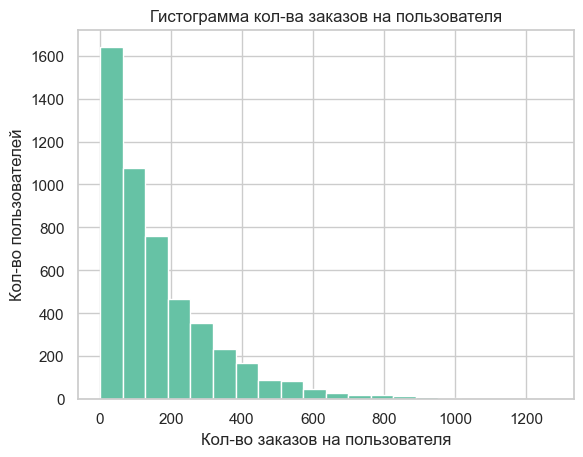

In [ ]:
data_cnt_orders = data_order['customer_id'].value_counts()
data_cnt_orders.hist(bins=20)
plt.xlabel('Кол-во заказов на пользователя')
plt.ylabel('Кол-во пользователей')
plt.title('Гистограмма кол-ва заказов на пользователя')
plt.show()

Распределение количества заказов похоже на экспоненциальное.

### 3.3. Пример 1. Оценка retention по году

С помощью Bootstrap оценим retention покупок пользователей из года в год и сравним retention из 2018 в 2019 год и из 2021 в 2022 год.

In [ ]:
def bootstrap(data, target_col):
    '''
    Bootstrap данных

    Параметры
        data — датафрейм с выборкой
        target_col — колонка с интересующей нас метрикой

    Возвращает
        data_boot — Bootstrap-выборка
    '''
    return data[target_col].sample(frac=1, replace=True)


def count_bootstrap_statistics(data, target_col, boot_fn, stat_fn, n_boot=10_000):
    '''
    Подсчёт Bootstrap-статистик методом подстановки

    Параметры
        data — датафрейм с выборкой
        target_col — колонка с интересующей нас метрикой
        boot_fn — функция, реализующая Bootstrap
        stat_fn — функция, считающая статистику
        n_boot — количество запусков Bootstrap

    Возвращает
        boot_stat — массив Bootstrap-статистик
    '''

    boot_stat = []
    for _ in tqdm(range(n_boot)):
        # Делаем Bootstrap данных
        data_boot = boot_fn(data, target_col)
        # Считаем Bootstrap-статистику и добавляем её в массив
        boot_stat.append(stat_fn(data_boot))

    return boot_stat

In [ ]:
data_order['order_dt'].dtype

dtype('<M8[ns]')

In [ ]:
data_2018_users = data_order[data_order['order_dt'].dt.year == 2018]['customer_id'].unique()
data_2019_users = pd.DataFrame(
    data={'customer_id' :data_order[data_order['order_dt'].dt.year == 2019]['customer_id'].unique()})
data_2021_users = data_order[data_order['order_dt'].dt.year == 2021]['customer_id'].unique()
data_2022_users = pd.DataFrame(
    data={'customer_id' :data_order[data_order['order_dt'].dt.year == 2022]['customer_id'].unique()})

data_2019_users['ret_year'] = data_2019_users['customer_id'].apply(
    lambda user: 1 if user in data_2018_users else 0)
data_2022_users['ret_year'] = data_2022_users['customer_id'].apply(
    lambda user: 1 if user in data_2021_users else 0)

data_2022_users

,customer_id,ret_year
0,R_01vNIayewjIIKMF,1
1,R_037XK72IZBJyF69,1
2,R_038ZU6kfQ5f89fH,1
3,R_03aEbghUILs9NxD,1
4,R_06RZP9pS7kONINr,1
...,...,...
4863,R_zd4E1BgAdaM2761,1
4864,R_zdLOP8JD2pe1brj,1
4865,R_zdQYFhfeqyBd2dH,1
4866,R_zfnsck2ZatnGtY5,1


In [ ]:
# Уровень доверия доверительного интервала
alpha = 0.95

# Считаем Bootstrap-статистики
boot_stat = count_bootstrap_statistics(data_2019_users, target_col='ret_year',
                                       boot_fn=bootstrap, stat_fn=np.mean)
# Строим Bootstrap-доверительный интервал
lb = np.quantile(boot_stat, q=(1 - alpha)/2)
rb = np.quantile(boot_stat, q=(1 + alpha)/2)
np.round([lb, rb], 3)

  0%|          | 0/10000 [00:00<?, ?it/s]

array([0.906, 0.922])

In [ ]:
# Уровень доверия доверительного интервала
alpha = 0.95

# Считаем Bootstrap-статистики
boot_stat = count_bootstrap_statistics(data_2022_users, target_col='ret_year',
                                       boot_fn=bootstrap, stat_fn=np.mean)
# Строим Bootstrap-доверительный интервал
lb = np.quantile(boot_stat, q=(1 - alpha)/2)
rb = np.quantile(boot_stat, q=(1 + alpha)/2)
np.round([lb, rb], 3)

  0%|          | 0/10000 [00:00<?, ?it/s]

array([0.974, 0.982])

Сравним полученный интервал с интервалом, который можно получить из ЦПТ.

In [ ]:
# Уровень доверия доверительного интервала
alpha = 0.95


# Считаем нужные параметры для доверительного интервала
ret = data_2022_users['ret_year'].mean()
stddev = np.sqrt(ret * (1 - ret))
z = sps.norm.ppf((1 + alpha) / 2)
n = len(data_2022_users)

# Строим  доверительный интервал по ЦПТ
lb = ret - z * stddev / np.sqrt(n)
rb = ret + z * stddev / np.sqrt(n)
np.round([lb, rb], 3)

array([0.974, 0.982])

Получаем абсолютно такой же интервал.

**Вывод:** retention в покупку из 2018 в 2019 год с вероятностью 95% находится в интервале от 90.6% до 92.2%, в то время как retention в покупку из 2021 в 2022 год с той же вероятностью находится в интервале от 97.4% до 98.2%. Это означает, что больше пользователей продолжают совершать покупки на Amazon из года в год.

### 3.4. Задача 1. Оценка доли пользователей, покупающих книги за 2019 год и за 2022 год

С помощью Bootstrap оцените долю пользователей, покупающих книги за 2019 год и за 2022 год.

In [ ]:
data['product_category'].value_counts()

product_category
ABIS_BOOK                        87619
PET_FOOD                         38256
GIFT_CARD                        27734
SHIRT                            27267
NUTRITIONAL_SUPPLEMENT           26913
                                 ...  
FUEL_INJECTOR                        1
FIRE_GRATE                           1
NONACTIVATED_GIFT_CARD               1
AUTO_CHEMICAL                        1
COMPUTER_VIDEO_GAME_CONTOLLER        1
Name: count, Length: 1871, dtype: int64

In [ ]:
data_book = data[data['product_category'] == 'ABIS_BOOK']
data_book_2019_users = data_book[data_book['order_dt'].dt.year == 2019]['customer_id'].unique()
data_book_2022_users = data_book[data_book['order_dt'].dt.year == 2022]['customer_id'].unique()

data_2019_users['buy_book_flg'] = data_2019_users['customer_id'].apply(
    lambda user: 1 if user in data_book_2018_users else 0)
data_2022_users['buy_book_flg'] = data_2022_users['customer_id'].apply(
    lambda user: 1 if user in data_book_2022_users else 0)
data_2022_users

,customer_id,ret_year,buy_book_flg
0,R_01vNIayewjIIKMF,1,0
1,R_037XK72IZBJyF69,1,1
2,R_038ZU6kfQ5f89fH,1,0
3,R_03aEbghUILs9NxD,1,1
4,R_06RZP9pS7kONINr,1,1
...,...,...,...
4863,R_zd4E1BgAdaM2761,1,1
4864,R_zdLOP8JD2pe1brj,1,1
4865,R_zdQYFhfeqyBd2dH,1,1
4866,R_zfnsck2ZatnGtY5,1,1


In [ ]:
# Уровень доверия доверительного интервала
alpha = 0.95

# Считаем Bootstrap-статистики
boot_stat = count_bootstrap_statistics(data_2019_users, target_col='buy_book_flg',
                                       boot_fn=bootstrap, stat_fn=np.mean)
# Строим Bootstrap-доверительный интервал
lb = np.quantile(boot_stat, q=(1 - alpha)/2)
rb = np.quantile(boot_stat, q=(1 + alpha)/2)
np.round([lb, rb], 3)

  0%|          | 0/10000 [00:00<?, ?it/s]

array([0.531, 0.56 ])

In [ ]:
# Уровень доверия доверительного интервала
alpha = 0.95

# Считаем Bootstrap-статистики
boot_stat = count_bootstrap_statistics(data_2022_users, target_col='buy_book_flg',
                                       boot_fn=bootstrap, stat_fn=np.mean)
# Строим Bootstrap-доверительный интервал
lb = np.quantile(boot_stat, q=(1 - alpha)/2)
rb = np.quantile(boot_stat, q=(1 + alpha)/2)
np.round([lb, rb], 3)

  0%|          | 0/10000 [00:00<?, ?it/s]

array([0.547, 0.574])

In [ ]:
# Уровень доверия доверительного интервала
alpha = 0.95


# Считаем нужные параметры для доверительного интервала
ret = data_2022_users['buy_book_flg'].mean()
stddev = np.sqrt(ret * (1 - ret))
z = sps.norm.ppf((1 + alpha) / 2)
n = len(data_2022_users)

# Строим  доверительный интервал по ЦПТ
lb = ret - z * stddev / np.sqrt(n)
rb = ret + z * stddev / np.sqrt(n)
np.round([lb, rb], 3)

array([0.547, 0.575])

**Вывод:**
* снова Bootstrap-доверительный интервал и доверительный интервал по ЦПТ почти совпали;
* доли пользователей, покупающих книги, за 2019 и за 2022 год отличаются незначимо.

## 3.5. Пример 2. Оценка среднего чека на заказ по годам

Оценим Bootstrap-доверительный интервал для среднего чека на заказ за 2019 и за 2022 год.

**<u>Замечание:</u>** в данном случае нужно рассматривать выборку не по пользователям, а по заказам. В предыдущих случаях мы делали неявное предположение, что пользователи независимы друг с другом. ***Сейчас же сделать предположение о независимости мы не можем:*** кто-то покупает, например, мало, но много раз, а кто-то — один раз, но очень много.

Средний чек — это отношение суммы всей выручки к количеству заказов.

В данном случае мы имеем дело с **метрикой отношения** (подробнее [тут](https://habr.com/ru/companies/X5Tech/articles/740476/)).


Что же делать в таком случае? Делать Bootstrap по пользователям и брать все их заказы. А дальше — оценивать средний чек как среднюю выручку по Bootstrap-пользователям!

In [ ]:
def bootstrap_users(data, target_col, user_col='customer_id'):
    """
    Делает одну Bootstrap-выборку пользователей и возвращает все их заказы.

    Параметры
        data — датафрейм с выборкой
        target_col — колонка с интересующей нас метрикой
        user_col — колонка с идентификатором пользователя

    Возвращает
        boot_data — новый датафрейм с Bootstrap-выборкой заказов
    """

    # Получаем список уникальных пользователей
    unique_users = data[user_col].unique()

    # Делаем Bootstrap пользователей с возвращением
    sampled_users = np.random.choice(unique_users, size=len(unique_users), replace=True)

    # Собираем все заказы выбранных пользователей
    boot_data = data[data[user_col].isin(sampled_users)].copy()

    # Добавим, сколько раз каждый пользователь попал в выборку (важно для повторов)
    user_counts = pd.Series(sampled_users).value_counts()

    # Повторим строки в соответствии с количеством выборов пользователя
    boot_data = boot_data.merge(user_counts.rename("replications"), left_on=user_col, right_index=True)
    boot_data = boot_data.loc[boot_data.index.repeat(boot_data['replications'])][target_col]

    return boot_data

In [ ]:
data_2019 = data[data['order_dt'].dt.year == 2019]
data_2022 = data[data['order_dt'].dt.year == 2022]
data_2022

,order_dt,unit_price,unit_count,order_region,product_category,customer_id,unit_revenue
130,2022-02-13,119.99,1.0,NJ,COMPUTER_DRIVE_OR_STORAGE,R_01vNIayewjIIKMF,119.99
131,2022-02-17,105.99,1.0,NJ,BED_FRAME,R_01vNIayewjIIKMF,105.99
132,2022-02-17,12.99,1.0,NJ,ELECTRONIC_CABLE,R_01vNIayewjIIKMF,12.99
133,2022-02-17,28.89,1.0,NJ,WIRELESS_ACCESSORY,R_01vNIayewjIIKMF,28.89
134,2022-02-19,11.58,1.0,NJ,IMMERSION_HEATER,R_01vNIayewjIIKMF,11.58
...,...,...,...,...,...,...,...
1850621,2022-12-20,16.99,1.0,OH,TRADING_CARDS_FACTORY_SEALED,R_zfnsck2ZatnGtY5,16.99
1850622,2022-12-20,15.66,1.0,OH,TRADING_CARDS_FACTORY_SEALED,R_zfnsck2ZatnGtY5,15.66
1850623,2022-12-20,7.49,1.0,OH,TRADING_CARDS_FACTORY_SEALED,R_zfnsck2ZatnGtY5,7.49
1850624,2022-12-27,10.99,1.0,OH,PLANNER,R_zfnsck2ZatnGtY5,10.99


In [ ]:
# Уровень доверия доверительного интервала
alpha = 0.95

# Считаем Bootstrap-статистики
boot_stat = count_bootstrap_statistics(data_2019, target_col='unit_price',
                                       boot_fn=bootstrap_users, stat_fn=np.mean)
# Строим Bootstrap-доверительный интервал
lb = np.quantile(boot_stat, q=(1 - alpha)/2)
rb = np.quantile(boot_stat, q=(1 + alpha)/2)
np.round([lb, rb], 3)

  0%|          | 0/10000 [00:00<?, ?it/s]

array([22.726, 23.527])

In [ ]:
# Уровень доверия доверительный интервала
alpha = 0.95

# Считаем Bootstrap-статистики
boot_stat = count_bootstrap_statistics(data_2022, target_col='unit_price',
                                       boot_fn=bootstrap_users, stat_fn=np.mean)
# Строим Bootstrap-доверительный интервал
lb = np.quantile(boot_stat, q=(1 - alpha)/2)
rb = np.quantile(boot_stat, q=(1 + alpha)/2)
np.round([lb, rb], 3)

  0%|          | 0/10000 [00:00<?, ?it/s]

array([22.59 , 23.377])

Сравним с доверительным интервалом по ЦПТ.

In [ ]:
# Уровень доверия доверительного интервала
alpha = 0.95


# Считаем нужные параметры для доверительного интервала
aov = data_2022['unit_price'].mean()
stddev = data_2022['unit_price'].std()
z = sps.norm.ppf((1 + alpha) / 2)
n = len(data_2022_users)

# Строим  доверительный интервал по ЦПТ
lb = aov - z * stddev / np.sqrt(n)
rb = aov + z * stddev / np.sqrt(n)
np.round([lb, rb], 3)

array([21.638, 24.326])

**Вывод:**
* здесь Bootstrap-доверительный интервал не совпал с интервалом по ЦПТ. Какой же правильный? По Bootstrap, так как ЦПТ не применима (заказы пользователей не независимы);
* средний чек за 2019 и за 2022 год отличаются незначимо.

## 4. Итоги семинара

С чем выходим с занятия:
- разобрались, почему мало — это не всегда хорошо (парадокс бразильских школ);
- разобрались, почему не всегда удаётся получить оценки из теории;
- узнали, как получать оценки параметров, основываясь только на выборке (Bootstrap);
- узнали, как делать Bootstrap, если наблюдения зависят от пользователей;
- узнали, в чём успех Amazon. 🙃

## 5. Полезные материалы

* [Парадокс с бразильскими школами](https://matheusfacure.github.io/python-causality-handbook/03-Stats-Review-The-Most-Dangerous-Equation.html)
* [Статья про Bootstrap от x5](https://habr.com/ru/companies/X5Tech/articles/679842/)